In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skcriteria as skc
from skcriteria.preprocessing import invert_objectives, scalers
from skcriteria.agg import simple, topsis
from skcriteria.pipeline import mkpipe
from skcriteria.cmp import RanksComparator, mkrank_cmp

Розробити програмний скрипт, що реалізує оцінювання ефективності впровадження нового
товару на ринку продукції. Вихідні дані містять 12 критеріїв, з яких 7 – максимізованих,
решта – мінімізованих. Кількість аналогічних товарів – 8. Вхідні дані занесені у файл. Формат
файлу, тип товару, зміст показників та критеріїв ефективності та їх значення обрати
самостійно.

In [267]:
INPUT_DATA_FILE = 'data.xlsx'

In [268]:
df = pd.read_excel(INPUT_DATA_FILE)

In [269]:
df

,Unnamed: 0,Критерій 1,Критерій 2,Критерій 3,Критерій 4,Критерій 5,Критерій 6,Критерій 7,Критерій 8,Критерій 9,Критерій 10,Критерій 11,Критерій 12
0,Товар 1,1.2,204.06,1.12,1.2,0.61,18.24,4.09,2.19,1.03,85.5,15.2,9.1
1,Товар 2,1.74,193.32,0.26,1.73,0.01,10.45,4.7,1.82,0.53,92,12.4,8.5
2,Товар 3,1.32,196.32,0.44,1.31,0.02,15,3.3,1.98,0.69,88.3,14.1,7.8
3,Товар 4,1.45,198.5,0.55,1.42,0.15,16.2,3.8,2.05,0.75,87.1,13.5,8
4,Товар 5,1.6,195.1,0.35,1.65,0.08,12.8,4.5,1.9,0.6,90.5,12.8,8.7
5,Товар 6,1.25,201.2,0.95,1.28,0.45,17.5,3.5,2.1,0.9,86.2,14.8,7.5
6,Товар 7,1.38,197.8,0.48,1.35,0.1,15.5,4.1,2,0.72,89.4,13.9,8.2
7,Товар 8,1.55,194.6,0.3,1.58,0.05,11.9,4.6,1.85,0.58,91.2,12.6,8.9
8,Товар 9,1.28,199.9,0.82,1.25,0.35,16.8,3.65,2.08,0.85,86.8,14.5,7.7
9,Товар 10,1.68,193.9,0.28,1.69,0.03,11.2,4.65,1.84,0.55,91.8,12.5,8.6


In [270]:
df.columns

Index(['Unnamed: 0', 'Критерій 1', 'Критерій 2', 'Критерій 3', 'Критерій 4',
       'Критерій 5', 'Критерій 6', 'Критерій 7', 'Критерій 8', 'Критерій 9',
       'Критерій 10', 'Критерій 11', 'Критерій 12'],
      dtype='str')

In [271]:
df.index

RangeIndex(start=0, stop=13, step=1)

In [272]:
df.rename(columns={'Unnamed: 0': 'Товари'}, inplace=True)
df.set_index('Товари', inplace=True)
df

,Критерій 1,Критерій 2,Критерій 3,Критерій 4,Критерій 5,Критерій 6,Критерій 7,Критерій 8,Критерій 9,Критерій 10,Критерій 11,Критерій 12
Товари,,,,,,,,,,,,
Товар 1,1.2,204.06,1.12,1.2,0.61,18.24,4.09,2.19,1.03,85.5,15.2,9.1
Товар 2,1.74,193.32,0.26,1.73,0.01,10.45,4.7,1.82,0.53,92,12.4,8.5
Товар 3,1.32,196.32,0.44,1.31,0.02,15,3.3,1.98,0.69,88.3,14.1,7.8
Товар 4,1.45,198.5,0.55,1.42,0.15,16.2,3.8,2.05,0.75,87.1,13.5,8
Товар 5,1.6,195.1,0.35,1.65,0.08,12.8,4.5,1.9,0.6,90.5,12.8,8.7
Товар 6,1.25,201.2,0.95,1.28,0.45,17.5,3.5,2.1,0.9,86.2,14.8,7.5
Товар 7,1.38,197.8,0.48,1.35,0.1,15.5,4.1,2,0.72,89.4,13.9,8.2
Товар 8,1.55,194.6,0.3,1.58,0.05,11.9,4.6,1.85,0.58,91.2,12.6,8.9
Товар 9,1.28,199.9,0.82,1.25,0.35,16.8,3.65,2.08,0.85,86.8,14.5,7.7


In [273]:
max_min_list = df.T['Критерій'].copy().tolist()
max_min_list

['max',
 'max',
 'max',
 'max',
 'max',
 'max',
 'max',
 'min',
 'min',
 'min',
 'min',
 'min']

In [274]:
df.drop('Критерій', axis=0, inplace=True)
df

,Критерій 1,Критерій 2,Критерій 3,Критерій 4,Критерій 5,Критерій 6,Критерій 7,Критерій 8,Критерій 9,Критерій 10,Критерій 11,Критерій 12
Товари,,,,,,,,,,,,
Товар 1,1.2,204.06,1.12,1.2,0.61,18.24,4.09,2.19,1.03,85.5,15.2,9.1
Товар 2,1.74,193.32,0.26,1.73,0.01,10.45,4.7,1.82,0.53,92,12.4,8.5
Товар 3,1.32,196.32,0.44,1.31,0.02,15,3.3,1.98,0.69,88.3,14.1,7.8
Товар 4,1.45,198.5,0.55,1.42,0.15,16.2,3.8,2.05,0.75,87.1,13.5,8
Товар 5,1.6,195.1,0.35,1.65,0.08,12.8,4.5,1.9,0.6,90.5,12.8,8.7
Товар 6,1.25,201.2,0.95,1.28,0.45,17.5,3.5,2.1,0.9,86.2,14.8,7.5
Товар 7,1.38,197.8,0.48,1.35,0.1,15.5,4.1,2,0.72,89.4,13.9,8.2
Товар 8,1.55,194.6,0.3,1.58,0.05,11.9,4.6,1.85,0.58,91.2,12.6,8.9
Товар 9,1.28,199.9,0.82,1.25,0.35,16.8,3.65,2.08,0.85,86.8,14.5,7.7


In [275]:
df.dtypes

Критерій 1     object
Критерій 2     object
Критерій 3     object
Критерій 4     object
Критерій 5     object
Критерій 6     object
Критерій 7     object
Критерій 8     object
Критерій 9     object
Критерій 10    object
Критерій 11    object
Критерій 12    object
dtype: object

In [276]:
df = df.astype(float)
df.dtypes

Критерій 1     float64
Критерій 2     float64
Критерій 3     float64
Критерій 4     float64
Критерій 5     float64
Критерій 6     float64
Критерій 7     float64
Критерій 8     float64
Критерій 9     float64
Критерій 10    float64
Критерій 11    float64
Критерій 12    float64
dtype: object

In [277]:
df.describe()

,Критерій 1,Критерій 2,Критерій 3,Критерій 4,Критерій 5,Критерій 6,Критерій 7,Критерій 8,Критерій 9,Критерій 10,Критерій 11,Критерій 12
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,1.441667,197.358333,0.534167,1.439167,0.169167,14.524167,4.095000,1.973333,0.712500,88.975000,13.625000,8.291667
std,0.174347,3.169278,0.279917,0.183078,0.194116,2.537771,0.469748,0.115312,0.151004,2.218159,0.942072,0.494439
min,1.200000,193.320000,0.260000,1.200000,0.010000,10.450000,3.300000,1.820000,0.530000,85.500000,12.400000,7.500000
25%,1.310000,194.975000,0.337500,1.302500,0.045000,12.575000,3.762500,1.887500,0.595000,87.025000,12.750000,7.950000
50%,1.415000,196.800000,0.450000,1.385000,0.090000,15.100000,4.095000,1.965000,0.695000,89.150000,13.700000,8.300000
75%,1.562500,198.850000,0.617500,1.597500,0.200000,16.350000,4.525000,2.057500,0.775000,90.675000,14.200000,8.625000
max,1.740000,204.060000,1.120000,1.730000,0.610000,18.240000,4.700000,2.190000,1.030000,92.000000,15.200000,9.100000


In [278]:
columns = df.columns
columns

Index(['Критерій 1', 'Критерій 2', 'Критерій 3', 'Критерій 4', 'Критерій 5',
       'Критерій 6', 'Критерій 7', 'Критерій 8', 'Критерій 9', 'Критерій 10',
       'Критерій 11', 'Критерій 12'],
      dtype='str')

In [279]:
matrix = df.to_numpy()
matrix

array([[1.2000e+00, 2.0406e+02, 1.1200e+00, 1.2000e+00, 6.1000e-01,
        1.8240e+01, 4.0900e+00, 2.1900e+00, 1.0300e+00, 8.5500e+01,
        1.5200e+01, 9.1000e+00],
       [1.7400e+00, 1.9332e+02, 2.6000e-01, 1.7300e+00, 1.0000e-02,
        1.0450e+01, 4.7000e+00, 1.8200e+00, 5.3000e-01, 9.2000e+01,
        1.2400e+01, 8.5000e+00],
       [1.3200e+00, 1.9632e+02, 4.4000e-01, 1.3100e+00, 2.0000e-02,
        1.5000e+01, 3.3000e+00, 1.9800e+00, 6.9000e-01, 8.8300e+01,
        1.4100e+01, 7.8000e+00],
       [1.4500e+00, 1.9850e+02, 5.5000e-01, 1.4200e+00, 1.5000e-01,
        1.6200e+01, 3.8000e+00, 2.0500e+00, 7.5000e-01, 8.7100e+01,
        1.3500e+01, 8.0000e+00],
       [1.6000e+00, 1.9510e+02, 3.5000e-01, 1.6500e+00, 8.0000e-02,
        1.2800e+01, 4.5000e+00, 1.9000e+00, 6.0000e-01, 9.0500e+01,
        1.2800e+01, 8.7000e+00],
       [1.2500e+00, 2.0120e+02, 9.5000e-01, 1.2800e+00, 4.5000e-01,
        1.7500e+01, 3.5000e+00, 2.1000e+00, 9.0000e-01, 8.6200e+01,
        1.4800e+01,

In [280]:
dm = skc.mkdm(matrix,
                max_min_list,
                alternatives=df.index.tolist(),
                criteria=columns)

In [281]:
dm.objectives

Критерій 1     MAX
Критерій 2     MAX
Критерій 3     MAX
Критерій 4     MAX
Критерій 5     MAX
Критерій 6     MAX
Критерій 7     MAX
Критерій 8     MIN
Критерій 9     MIN
Критерій 10    MIN
Критерій 11    MIN
Критерій 12    MIN
Name: Objectives, dtype: object

In [282]:
dm.weights

Критерій 1     1.0
Критерій 2     1.0
Критерій 3     1.0
Критерій 4     1.0
Критерій 5     1.0
Критерій 6     1.0
Критерій 7     1.0
Критерій 8     1.0
Критерій 9     1.0
Критерій 10    1.0
Критерій 11    1.0
Критерій 12    1.0
Name: Weights, dtype: float64

Weighted Sum Model

In [283]:
wsm_pipe = mkpipe(
    invert_objectives.InvertMinimize(),
    scalers.VectorScaler(target="matrix"),
    scalers.SumScaler(target="weights"),
    simple.WeightedSumModel()
)

In [284]:
wsm_rank = wsm_pipe.evaluate(dm)
wsm_rank

Alternatives,Товар 1,Товар 2,Товар 3,Товар 4,Товар 5,Товар 6,Товар 7,Товар 8,Товар 9,Товар 10,Товар 11,Товар 12
Rank,1,8,12,4,5,2,9,10,3,7,11,6


In [285]:
for i, value in wsm_rank.e_.items():
    print(f'{i}: {value}')
    print()

score: [0.32739935 0.26647464 0.25107834 0.27510413 0.27040188 0.31062293
 0.26524799 0.26389421 0.29626416 0.26671368 0.25984915 0.26974781]



Weighted Product Model

In [286]:
wpm_pipe = mkpipe(
    invert_objectives.InvertMinimize(),
    scalers.VectorScaler(target="matrix"),
    scalers.SumScaler(target="weights"),
    simple.WeightedProductModel()
)

In [287]:
wpm_rank = wpm_pipe.evaluate(dm)
wpm_rank

Alternatives,Товар 1,Товар 2,Товар 3,Товар 4,Товар 5,Товар 6,Товар 7,Товар 8,Товар 9,Товар 10,Товар 11,Товар 12
Rank,1,12,11,4,7,2,6,9,3,10,8,5


In [288]:
for i, value in wpm_rank.e_.items():
    print(f'{i}: {value}')
    print()

score: [-0.51540041 -0.66950041 -0.65724832 -0.5647647  -0.58957748 -0.52213256
 -0.58748513 -0.61515969 -0.53479439 -0.62931637 -0.60870954 -0.57872001]



TOPSIS

In [289]:
topsis_pipe = mkpipe(
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    scalers.SumScaler(target="weights"),
    topsis.TOPSIS(),
)

In [290]:
topsis_rank = topsis_pipe.evaluate(dm)
topsis_rank

Alternatives,Товар 1,Товар 2,Товар 3,Товар 4,Товар 5,Товар 6,Товар 7,Товар 8,Товар 9,Товар 10,Товар 11,Товар 12
Rank,1,8,12,4,6,2,7,10,3,9,11,5


In [291]:
for i, value in topsis_rank.e_.items():
    print(f'{i}: {value}')
    print()

ideal: [ 0.02884169  0.0248702   0.04508331  0.02870553  0.05839056  0.0297967
  0.02744533 -0.02215238 -0.01753709 -0.02311014 -0.02184559 -0.02172406]

anti_ideal: [ 0.01989082  0.02356124  0.01046577  0.01991135  0.00095722  0.01707103
  0.01927012 -0.02665589 -0.03408152 -0.02486705 -0.02677846 -0.02635852]

similarity: [0.75192359 0.25470025 0.20220625 0.31478531 0.26129313 0.674815
 0.25619192 0.24095084 0.56084756 0.25123752 0.2268913  0.27011951]



In [292]:
display(wsm_rank, wpm_rank, topsis_rank)

Alternatives,Товар 1,Товар 2,Товар 3,Товар 4,Товар 5,Товар 6,Товар 7,Товар 8,Товар 9,Товар 10,Товар 11,Товар 12
Rank,1,8,12,4,5,2,9,10,3,7,11,6


Alternatives,Товар 1,Товар 2,Товар 3,Товар 4,Товар 5,Товар 6,Товар 7,Товар 8,Товар 9,Товар 10,Товар 11,Товар 12
Rank,1,12,11,4,7,2,6,9,3,10,8,5


Alternatives,Товар 1,Товар 2,Товар 3,Товар 4,Товар 5,Товар 6,Товар 7,Товар 8,Товар 9,Товар 10,Товар 11,Товар 12
Rank,1,8,12,4,6,2,7,10,3,9,11,5


In [293]:
rcmp = RanksComparator([("WSM", wsm_rank),
                        ("WPM", wpm_rank),
                        ("TOPSIS", topsis_rank)], extra={})
rcmp

<RanksComparator [ranks=['WSM', 'WPM', 'TOPSIS']]>

<Axes: xlabel='Method', ylabel='Alternatives'>

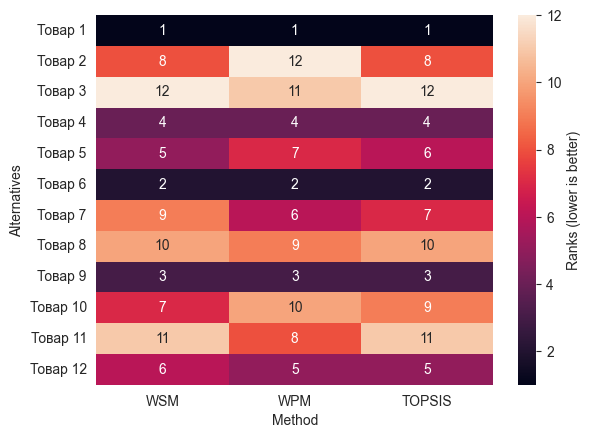

In [294]:
rcmp.plot("heatmap")

In [295]:
rcmp.corr(method="pearson")

Method,WSM,WPM,TOPSIS
Method,,,
WSM,1.000000,0.825175,0.965035
WPM,0.825175,1.000000,0.895105
TOPSIS,0.965035,0.895105,1.000000


In [296]:
rcmp.r2_score()

Method,WSM,WPM,TOPSIS
Method,,,
WSM,1.00000,0.65035,0.93007
WPM,0.65035,1.00000,0.79021
TOPSIS,0.93007,0.79021,1.00000


<Axes: xlabel='Method', ylabel='Method'>

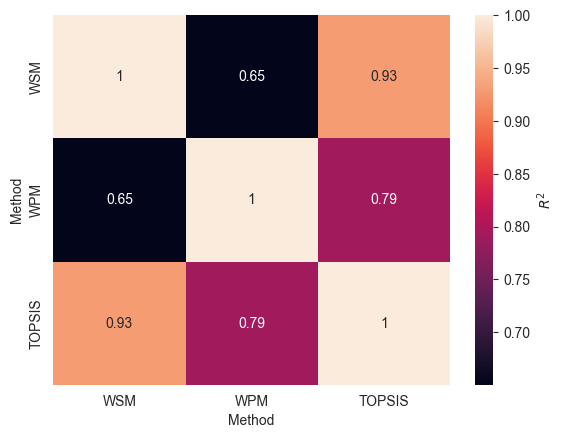

In [297]:
rcmp.plot("r2_score")